## Catastrophic vs non-catastrophic collision

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy import stats
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100
plt.rcParams['figure.figsize'] = (14, 8)

# Create output directory for figures
figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

print("Setup complete. Ready for data analysis.")

Setup complete. Ready for data analysis.


In [16]:
def load_and_process_result(filename):
    """
    Load a result CSV file and process it with calculated metrics
    """
    if not os.path.exists(filename):
        print(f"Warning: {filename} not found")
        return None
    
    df = pd.read_csv(filename)
    
    # Parse vector columns
    def parse_vector_column(column):
        try:
            return column.apply(
                lambda x: np.fromstring(
                    x.strip("[]"),
                    sep=" "
                )
            )
        except:
            return None
    
    # Parse vectors
    if "Velocity [m/s]" in df.columns:
        df["Velocity_vec"] = parse_vector_column(df["Velocity [m/s]"])
        df["Vx"] = df["Velocity_vec"].apply(lambda x: x[0] if x is not None else np.nan)
        df["Vy"] = df["Velocity_vec"].apply(lambda x: x[1] if x is not None else np.nan)
        df["Vz"] = df["Velocity_vec"].apply(lambda x: x[2] if x is not None else np.nan)
        df["Velocity_norm"] = df["Velocity_vec"].apply(lambda x: np.linalg.norm(x) if x is not None else np.nan)
    
    if "Ejection Velocity [m/s]" in df.columns:
        df["Ejection_vec"] = parse_vector_column(df["Ejection Velocity [m/s]"])
        df["Ejection_norm"] = df["Ejection_vec"].apply(lambda x: np.linalg.norm(x) if x is not None else np.nan)
    
    if "Position [m]" in df.columns:
        df["Position_vec"] = parse_vector_column(df["Position [m]"])
    
    # Calculated metrics
    if "Mass [kg]" in df.columns and "Area [m^2]" in df.columns:
        df["Mass_to_Area"] = df["Mass [kg]"] / df["Area [m^2]"]
        df["Log_Mass"] = np.log10(df["Mass [kg]"])
    
    return df

def save_figure(fig, name):
    """Save figure to analysis_figures directory"""
    fig.savefig(figures_dir / f"{name}.png", dpi=100, bbox_inches='tight')
    print(f"Saved: {name}.png")

print("Helper functions defined.")

Helper functions defined.


In [17]:
output_files = {
    'non catastrophic': '../../output/non_cat_result.csv',
    'catastrophic, high velocity': '../../output/cat_high_velocity_result.csv',
    'catastrophic, low velocity': '../../output/cat_low_velocity_result.csv'
}

output_data = {}
for label, filename in output_files.items():
    df = load_and_process_result(filename)
    if df is not None:
        output_data[label] = df
        print(f"✓ Loaded {label}: {len(df)} fragments")
    else:
        print(f"✗ Failed to load {label}")

✓ Loaded non catastrophic: 3006 fragments
✓ Loaded catastrophic, high velocity: 4044 fragments
✓ Loaded catastrophic, low velocity: 4044 fragments


In [18]:
velocity_data = {}
velocity_stats = {}

for label, filename in output_files.items():
    df = load_and_process_result(filename)
    if df is not None:
        velocity_data[label] = df
        velocity_stats[label] = {
            'count': len(df),
            'mean_vel': df['Velocity_norm'].mean() if 'Velocity_norm' in df.columns else 0,
            'max_vel': df['Velocity_norm'].max() if 'Velocity_norm' in df.columns else 0,
            'std_vel': df['Velocity_norm'].std() if 'Velocity_norm' in df.columns else 0,
            'mean_mass': df['Mass [kg]'].mean() if 'Mass [kg]' in df.columns else 0,
            'total_mass': df['Mass [kg]'].sum() if 'Mass [kg]' in df.columns else 0,
        }
        print(f"✓ Loaded {label}: {len(df)} fragments, mean_vel={velocity_stats[label]['mean_vel']:.0f} m/s")
    else:
        print(f"✗ Failed to load {label}")

print(f"\n✓ Total velocity scenarios loaded: {len(velocity_data)}")

✓ Loaded non catastrophic: 3006 fragments, mean_vel=334 m/s
✓ Loaded catastrophic, high velocity: 4044 fragments, mean_vel=5033 m/s
✓ Loaded catastrophic, low velocity: 4044 fragments, mean_vel=1860 m/s

✓ Total velocity scenarios loaded: 3


Saved: scenario_comparison_metrics.png


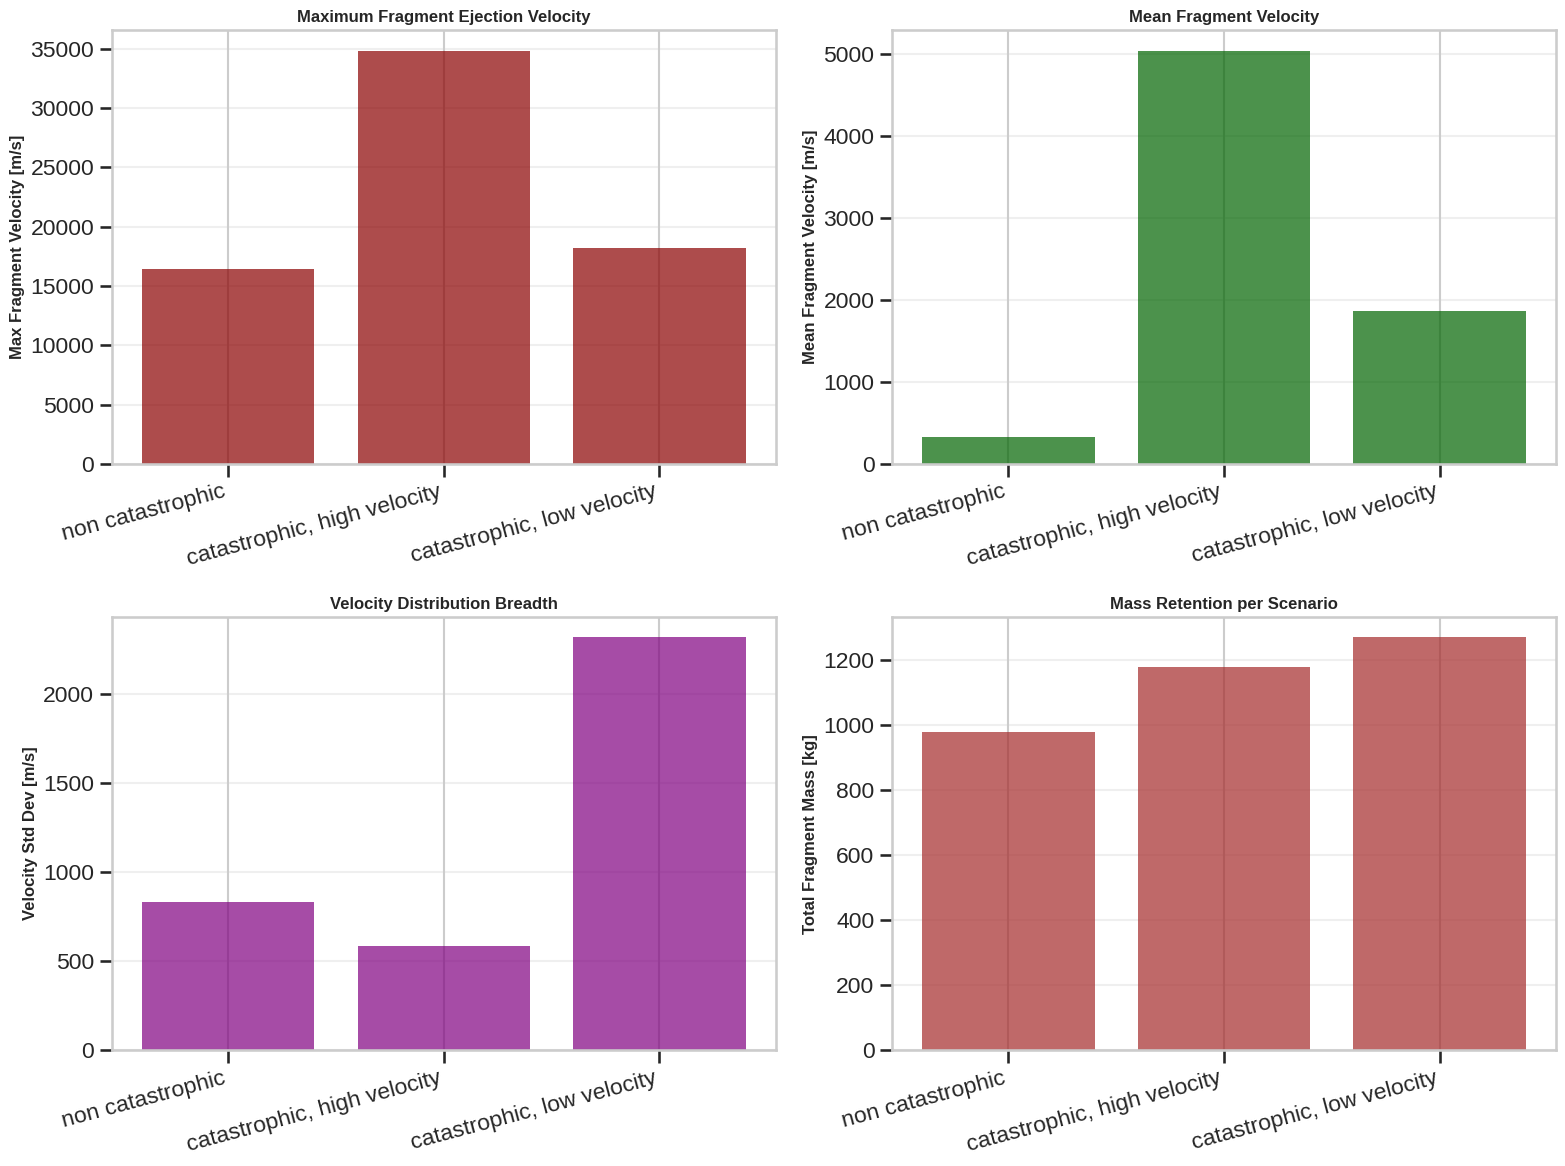


ENERGY METRICS SUMMARY

NON CATASTROPHIC:
  Max velocity: 16425.69 m/s
  Mean velocity: 333.9 m/s ±831.4 m/s
  Total mass: 980.02 kg
  Fragment count: 3006

CATASTROPHIC, HIGH VELOCITY:
  Max velocity: 34821.86 m/s
  Mean velocity: 5033.3 m/s ±587.8 m/s
  Total mass: 1180.83 kg
  Fragment count: 4044

CATASTROPHIC, LOW VELOCITY:
  Max velocity: 18195.06 m/s
  Mean velocity: 1860.1 m/s ±2316.5 m/s
  Total mass: 1270.37 kg
  Fragment count: 4044


In [ ]:

# Energy metrics across scenarios
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use the actual keys from our loaded data
scenario_labels = list(velocity_data.keys())

# Prepare metrics arrays
max_velocities = []
mean_velocities = []
velocity_std = []
mass_retention = []

for label in scenario_labels:
    df = velocity_data[label]
    if 'Velocity_norm' in df.columns:
        max_velocities.append(df['Velocity_norm'].max())
        mean_velocities.append(df['Velocity_norm'].mean())
        velocity_std.append(df['Velocity_norm'].std())
        
        if 'Mass [kg]' in df.columns:
            mass_retention.append(df['Mass [kg]'].sum())
        else:
            mass_retention.append(0)
    else:
        max_velocities.append(0)
        mean_velocities.append(0)
        velocity_std.append(0)
        mass_retention.append(0)

# Subplot 1: Max fragment velocity
ax = axes[0, 0]
ax.bar(scenario_labels, max_velocities, color='darkred', alpha=0.7, label='Max ejection velocity')
ax.set_ylabel('Max Fragment Velocity [m/s]', fontsize=12, fontweight='bold')
ax.set_title('Maximum Fragment Ejection Velocity', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Subplot 2: Mean fragment velocity
ax = axes[0, 1]
ax.bar(scenario_labels, mean_velocities, color='darkgreen', alpha=0.7, label='Mean fragment velocity')
ax.set_ylabel('Mean Fragment Velocity [m/s]', fontsize=12, fontweight='bold')
ax.set_title('Mean Fragment Velocity', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Subplot 3: Velocity distribution spread (std dev)
ax = axes[1, 0]
ax.bar(scenario_labels, velocity_std, color='purple', alpha=0.7, label='Velocity std dev')
ax.set_ylabel('Velocity Std Dev [m/s]', fontsize=12, fontweight='bold')
ax.set_title('Velocity Distribution Breadth', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Subplot 4: Mass retention
ax = axes[1, 1]
ax.bar(scenario_labels, mass_retention, color='brown', alpha=0.7, label='Total fragment mass')
ax.set_ylabel('Total Fragment Mass [kg]', fontsize=12, fontweight='bold')
ax.set_title('Mass Retention per Scenario', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
save_figure(fig, 'scenario_comparison_metrics')
plt.show()

print("\n" + "="*80)
print("ENERGY METRICS SUMMARY")
print("="*80)
for label in scenario_labels:
    stats_val = velocity_stats[label]
    print(f"\n{label.upper()}:")
    print(f"  Max velocity: {stats_val['max_vel']:.2f} m/s")
    print(f"  Mean velocity: {stats_val['mean_vel']:.1f} m/s ±{stats_val['std_vel']:.1f} m/s")
    print(f"  Total mass: {stats_val['total_mass']:.2f} kg")
    print(f"  Fragment count: {stats_val['count']}")

Saved: fragment_allocation_generalized.png


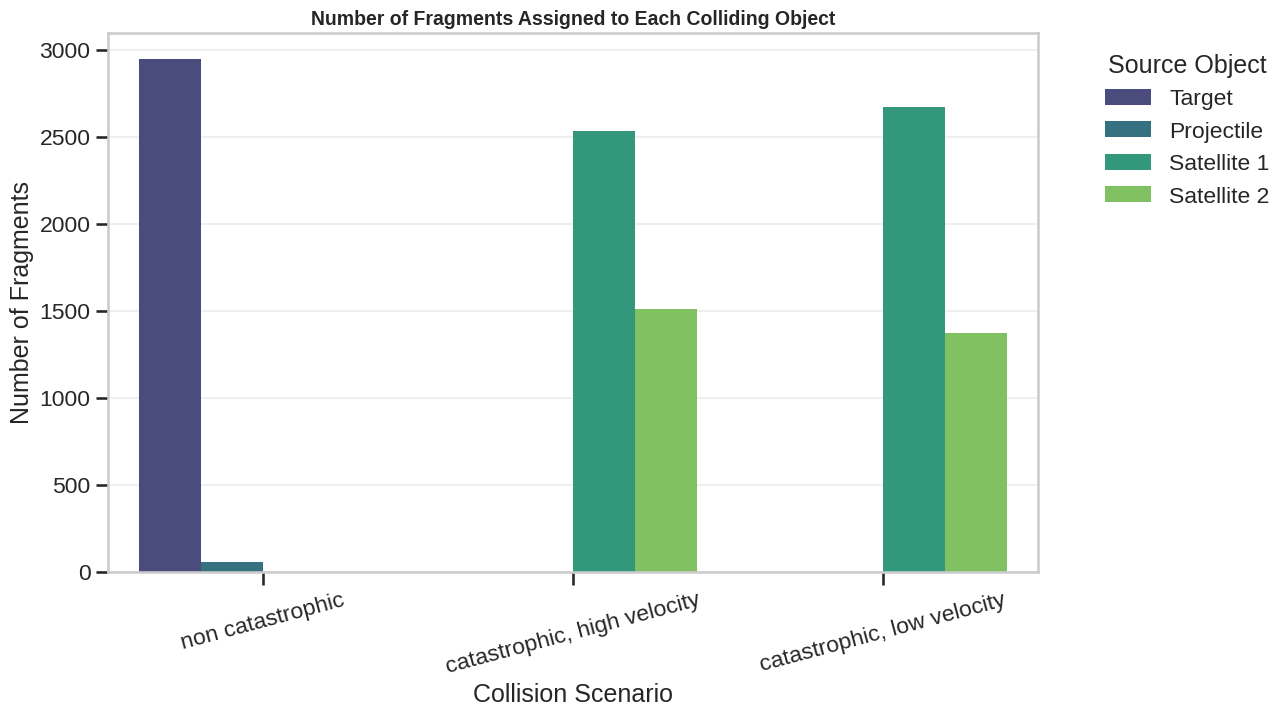

In [20]:
import re

# 1. Fragment Allocation (Generalized for Satellite/Target/Projectile)
plt.figure(figsize=(12, 7))

all_counts = []
for label, df in output_data.items():
    def identify_parent(name):
        # Split by '(' or '-' to get the base name (e.g., "Satellite 1", "Target")
        # Then strip whitespace
        parts = re.split(r'[\(\-]', str(name))
        return parts[0].strip()

    df['Parent_Object'] = df['Name'].apply(identify_parent)
    counts = df['Parent_Object'].value_counts().reset_index()
    counts.columns = ['Parent', 'Count']
    counts['Scenario'] = label
    all_counts.append(counts)

df_counts = pd.concat(all_counts)

# Plotting
sns.barplot(data=df_counts, x='Scenario', y='Count', hue='Parent', palette="viridis")
plt.title("Number of Fragments Assigned to Each Colliding Object", fontsize=14, fontweight='bold')
plt.ylabel("Number of Fragments")
plt.xlabel("Collision Scenario")
plt.xticks(rotation=15)
plt.legend(title="Source Object", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

save_figure(plt.gcf(), 'fragment_allocation_generalized')
plt.show()

Saved: velocity_distribution_kde.png


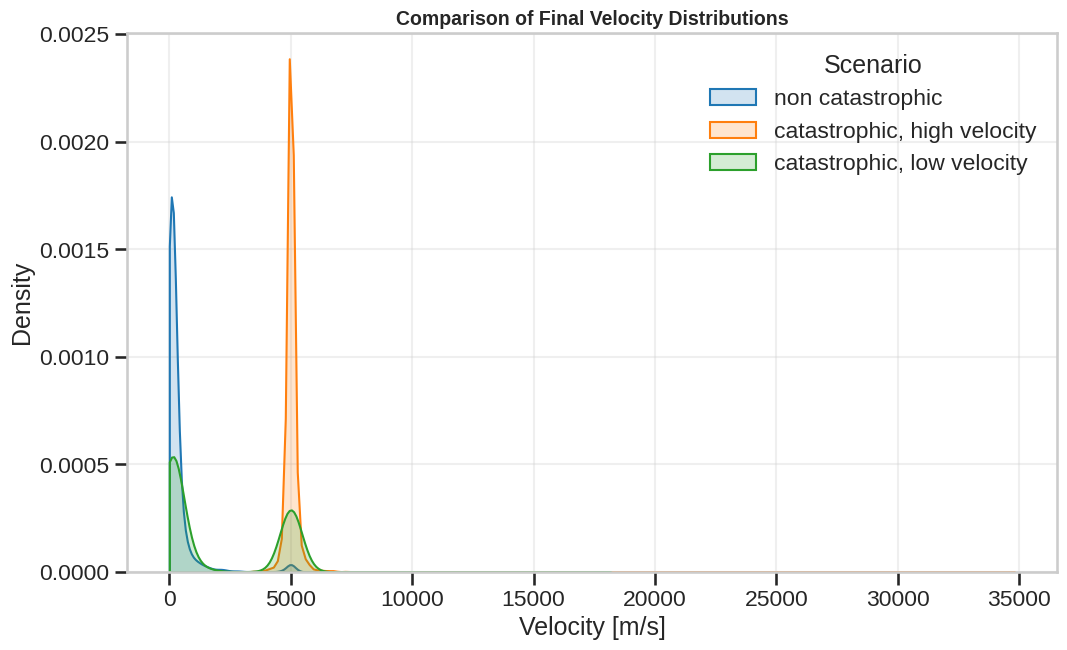

In [21]:
# 2. Final Velocity Distribution
plt.figure(figsize=(12, 7))

for label, df in output_data.items():
    sns.kdeplot(data=df, x="Velocity_norm", label=label, fill=True, alpha=0.2, cut=0)

plt.title("Comparison of Final Velocity Distributions", fontsize=14, fontweight='bold')
plt.xlabel("Velocity [m/s]")
plt.ylabel("Density")
plt.legend(title="Scenario")
plt.grid(True, alpha=0.3)

save_figure(plt.gcf(), 'velocity_distribution_kde')
plt.show()

Saved: mass_distribution_log.png


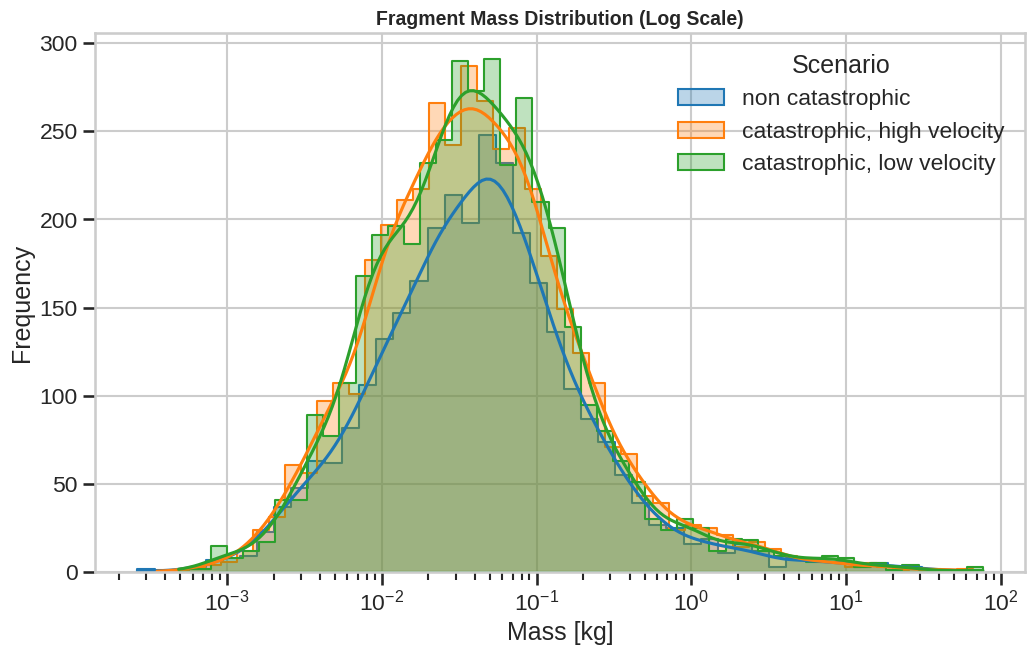

In [22]:
# 3. Mass Distribution
plt.figure(figsize=(12, 7))

for label, df in output_data.items():
    # Filter for positive mass to avoid log errors
    valid_mass = df[df['Mass [kg]'] > 0]
    sns.histplot(data=valid_mass, x="Mass [kg]", label=label, kde=True, 
                 element="step", log_scale=True, alpha=0.3)

plt.title("Fragment Mass Distribution (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Mass [kg]")
plt.ylabel("Frequency")
plt.legend(title="Scenario")

save_figure(plt.gcf(), 'mass_distribution_log')
plt.show()

Saved: length_distribution_log.png


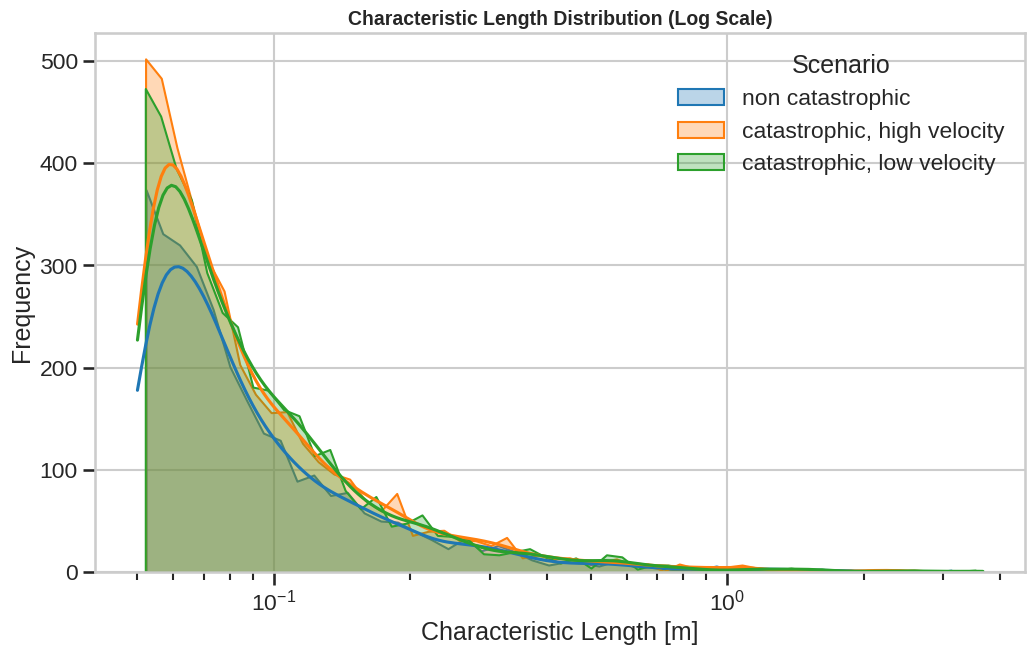

In [23]:
# 4. Characteristic Length Distribution
plt.figure(figsize=(12, 7))

col_len = "Characteristic Length [m]"

for label, df in output_data.items():
    if col_len in df.columns:
        valid_len = df[df[col_len] > 0]
        sns.histplot(data=valid_len, x=col_len, label=label, kde=True, 
                     element="poly", log_scale=True, alpha=0.3)

plt.title("Characteristic Length Distribution (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Frequency")
plt.legend(title="Scenario")

save_figure(plt.gcf(), 'length_distribution_log')
plt.show()

Saved: am_ratio_distribution.png


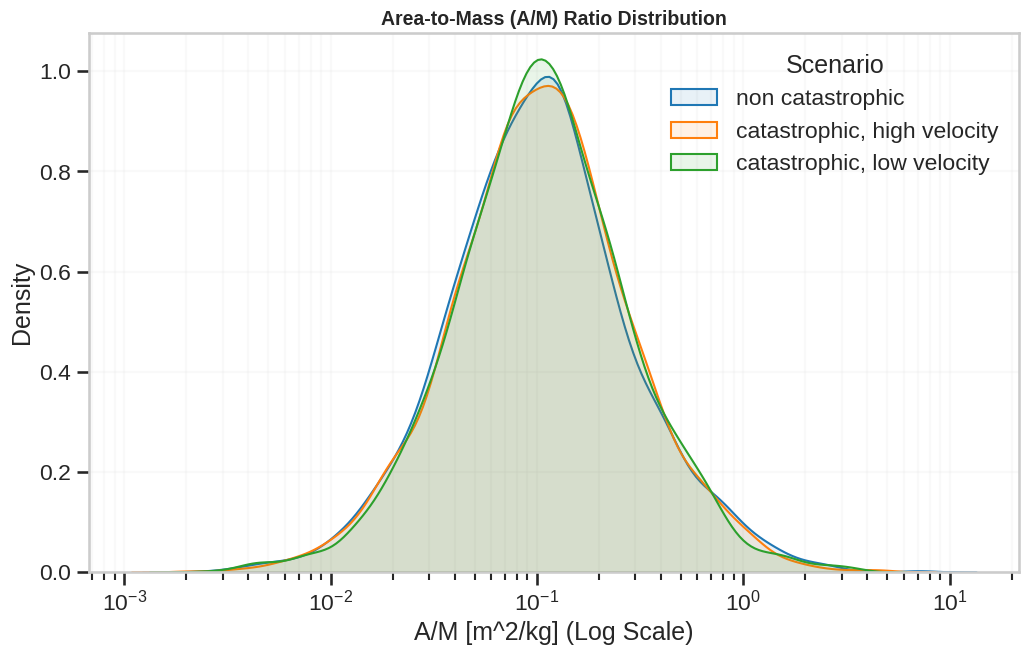

In [24]:
# 5. Area-to-Mass (A/M) Ratio Distribution
plt.figure(figsize=(12, 7))

am_col = "A/M [m^2/kg]"

for label, df in output_data.items():
    if am_col in df.columns:
        sns.kdeplot(data=df[df[am_col] > 0], x=am_col, label=label, 
                    log_scale=True, fill=True, alpha=0.1)

plt.title("Area-to-Mass (A/M) Ratio Distribution", fontsize=14, fontweight='bold')
plt.xlabel("A/M [m^2/kg] (Log Scale)")
plt.ylabel("Density")
plt.legend(title="Scenario")
plt.grid(True, which="both", ls="-", alpha=0.1)

save_figure(plt.gcf(), 'am_ratio_distribution')
plt.show()